# Exploring ASTER L1T Radiance

**Authors:** Nathan Roberts and Erik Bolch
Last Updated: February 3, 2026

> &#128216; **Learning Objectives**
>
> 1. Query the available ASTER Collections using `earthaccess`
> 2. Search for [ASTER L1T](https://doi.org/10.5067/ASTER/AST_L1T.004) granules using `earthaccess`
> 3. Open and visualize ASTER L1T data

### Summary  

This tutorial was developed to provide a basic outline on how to programically access [Advanced Spaceborne Thermal Emission and Reflection Radiometer (ASTER)](https://terra.nasa.gov/about/terra-instruments/aster) Version 4. ASTER version 4 is a result of the [Final ASTER Data Processing Campaign](https://www.earthdata.nasa.gov/news/feature-articles/nasa-begins-final-aster-data-processing-campaign) undertaken at NASA's [Land Processes Distributed Active Archive Center (LP DAAC)](https://www.earthdata.nasa.gov/centers/lp-daac). ASTER Version 4 includes **11 products** all of which are archived in the NASA Earthdata Cloud. In this notebook, we will show how to search, discover and visualize ASTER Version 4 data for the [Railroad Valley](https://www.usgs.gov/media/images/railroad-valley-playa), Nevada, USA using the `earthaccess` and `rioxarray` libraries. Specifically, this tutorial will show how to find the [ASTER Level-1 Precision Terrain Corrected Registered At-Sensor Radiance V004 (AST_L1T)](https://doi.org/10.5067/ASTER/AST_L1T.004) data available in the Earthdata Cloud for our specific time period, bands (layers), and region of interest. After finding the desired data, we will load subsets of the Cloud Optimized GeoTIFFs (COGs) into a Jupyter Notebook directly from the cloud. we will cover how to search for, process and "stack" the ASTER data over a region of interest into an [xarray](http://xarray.pydata.org/en/stable/) data array, then filter and visualize a Short-wave infrared (SWIR) composite image.

### Background  

Launched December 18, 1999 aboard NASA's [Terra](https://terra.nasa.gov/) satellite ASTER has acquired more than 3 million unique images of the Earth's Surface. ASTER acquires 15 to 90 square meter images of the Earth in 14 different wavelengths ranging from visible to infrared light. Historically, most ASTER data products were produced using the Simple, Scalable, Script Based Science Processor for Missions (S4PM) on demand architecture. With the [Final ASTER Data Processing Campaign](https://www.earthdata.nasa.gov/news/feature-articles/nasa-begins-final-aster-data-processing-campaign), 11 Version 4 ASTER Data products are now archived in COG format stored in the Earthdata cloud environment which enables users greater access to the ASTER archive. ASTER data is useful for a variety of areas including creating maps of land surface temperature, emissivity reflectance and elevation. Specific applications for ASTER data include, surface mineral resource exploration, tracking volcanoes, and tracking land cover change. The table below denotes the products available in ASTER Version 4.

|Product|Product Page|Collection Shortname|
|:---|:---|:---|
|ASTER L1A Reconstructed Unprocessed Instrument Data|https://doi.org/10.5067/ASTER/AST_L1A.004|AST_L1A|
|ASTER L1B Registered Radiance at the Sensor|https://doi.org/10.5067/ASTER/AST_L1B.004|AST_L1B|
|ASTER Level 1T Precision Terrain Corrected Registered At-Sensor Radiance|https://doi.org/10.5067/ASTER/AST_L1T.004|AST_L1T|
|ASTER L2 Surface Radiance TIR|https://doi.org/10.5067/ASTER/AST_09T.004|AST_09T|
|ASTER L2 Surface Kinetic Temperature|https://doi.org/10.5067/ASTER/AST_08.004|AST_08|
|ASTER L2 Surface Emissivity|https://doi.org/10.5067/ASTER/AST_05.004|AST_05|
|ASTER L2 Surface Radiance VNIR and SWIR|https://doi.org/10.5067/ASTER/AST_09.004|AST_09|
|ASTER L2 Surface Radiance VNIR and Crosstalk Corrected SWIR V004|https://doi.org/10.5067/aster/ast_09xt.004|AST_09XT|
|ASTER L2 Surface Reflectance VNIR and SWIR|https://doi.org/10.5067/ASTER/AST_07.004| AST_07|
|ASTER L2 Surface Reflectance VNIR and Crosstalk Corrected SWIR|https://doi.org/10.5067/ASTER/AST_07XT.004|AST_07XT|
|ASTER Digital Elevation Model|https://doi.org/10.5067/ASTER/AST14DEM.004|AST14DEM|


### Requirements  

- A [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account is required to download the data used in this tutorial. You can create an account at the link provided.

- A compatible Python environment. Please refer to the [setup instructions](https://github.com/nasa/LPDAAC-Data-Resources/blob/main/setup/setup_instructions_python.md) in the [LPDAAC-Data-Resources repository](https://github.com/nasa/LPDAAC-Data-Resources).

### Data Used  

+ **ASTER Level 1T Precision Terrain Corrected Registered At-Sensor Radiance**([AST_L1T](https://doi.org/10.5067/ASTER/AST_L1T.004))
 
    - Variables (layers):  
        - [SWIR_Band4](https://cmr.earthdata.nasa.gov/search/concepts/V3489841927-LPCLOUD.html)<br>
        - [SWIR_Band6](https://cmr.earthdata.nasa.gov/search/concepts/V3489841990-LPCLOUD.html)<br>
        - [SWIR_Band8](https://cmr.earthdata.nasa.gov/search/concepts/V3489842004-LPCLOUD.html)<br>
 
 >**Important:** [ASTER Shortwave Infrared (SWIR) bands are no longer provided with data acquired after April 2008](https://lpdaac.usgs.gov/documents/1661/ASTER_SWIR_User_Advisory_Jan_12_2009.pdf)


### Tutorial Outline  

1. [**Getting Started**](#getstarted)<br>
    1.1 Import Packages<br>
    1.2 Setup Current Working Directory<br>
    1.3 Earthdata Login Authentication<br>
2. [**Exploring ASTER Version 4 Data Collections and Granules**](#find)<br>
    2.1 Search for ASTER Version 4 Data Collections<br>
    2.2 Define Our Query Parameters<br>
    2.3 Search for Data Granules for AST_L1T Data Collection<br>
3. [**Accessing AST_L1T COGs Data**](#cloudaccess)<br>
    3.1 Group by Band<br>
4. [**Processing AST_L1T Data**](#process)<br>
    4.1 Load AST_L1T Data and Subset Spatially<br>
    4.2 Merge Our subset AST_L1T Data<br>
5. [**Visualizations of ASTER L1T Data**](#Visualizations)<br>
    5.1 Visualize three SWIR bands using `matplotlib`<br>
    5.2 Create and Visualize Three band RGB Composite<br>

## 1. Getting Started<a id="getstarted"></a>

### 1.1 Import Packages 

Import the required packages.

In [1]:
import os
from datetime import datetime
from collections import defaultdict
import numpy as np
import pandas as pd
import geopandas as gp
from osgeo import gdal
import xarray as xr
import rioxarray as rxr
import hvplot.xarray
import earthaccess
import holoviews as hv
import folium
from folium import Marker
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import math
import warnings

warnings.filterwarnings("ignore")
hv.extension('bokeh')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### 1.2 Setup Current Working Directory

We will use a directory called `data` as the default working directory for the tutorial. Any required ancillary files will be read from there also any outputs downloaded will be written in this folder.

In [2]:
os.chdir('../../data')

### 1.3 Earthdata Login Authentication

We will use the [earthaccess](https://github.com/nsidc/earthaccess#readme) package for authentication. `earthaccess` can either create a new local .netrc file to store credentials or validate that one exists already in you user profile. If you do not have a .netrc file, you will be prompted for your credentials and one will be created. 

In [3]:
earthaccess.login(persist=True)

## 2. Exploring ASTER Version 4 Data Collections and Granules using `earthaccess` <a id="find"></a>

To find ASTER Version 4 data, we will use the `earthaccess` Python library to search [NASA's Common Metadata Repository (CMR)](https://www.earthdata.nasa.gov/about/esdis/eosdis/cmr) for ASTER Version 4 data collections. We will use a GeoJSON file containing our region of interest (ROI) to search for data granules that intersect. To do this, we will simplify this region to a bounding box and extract the bounding coordinates from the GeoPandas object after opening the file.


### 2.1 Search for ASTER Version 4 Collections
With `earthaccess` we can locate all of the available ASTER Version 4 Collections using the keyword argument "ASTER 004". We will use the collection shortname for the ASTER Level-1 Precision Terrain Corrected Registered At-Sensor Radiance V004 collection to locate specific granules later. A dataframe is created for the results for viewing the results where each row include information returned for each collection. 

In [4]:
collections = earthaccess.search_datasets(
    keyword="ASTER 004",
    cloud_hosted=True)

print(f'ASTER Version 4 Collections found: {len(collections)}')

ASTER Version 4 Collections found: 25


In [5]:
collections_info = [
    {
        'short_name': c.summary()['short-name'],
        'collection_concept_id': c.summary()['concept-id'],
        'version': c.summary()['version'],
        'entry_title': c['umm']['EntryTitle']
    }
    for c in collections
]

In [6]:
pd.DataFrame(collections_info)

,short_name,collection_concept_id,version,entry_title
0,AST_L1T,C3306888411-LPCLOUD,004,ASTER Level 1T Precision Terrain Corrected Reg...
1,AST14DEM,C3306855744-LPCLOUD,004,ASTER Digital Elevation Model V004
2,AST_07XT,C3306884993-LPCLOUD,004,ASTER L2 Surface Reflectance VNIR and Crosstal...
3,AST_07,C3306877498-LPCLOUD,004,ASTER L2 Surface Reflectance VNIR and SWIR V004
4,AST_05,C3306858335-LPCLOUD,004,ASTER L2 Surface Emissivity V004
5,AST_08,C3306885674-LPCLOUD,004,ASTER L2 Surface Kinetic Temperature V004
6,AST_L1B,C3306888201-LPCLOUD,004,ASTER L1B Registered Radiance at the Sensor V004
7,AST_09T,C3306887110-LPCLOUD,004,ASTER L2 Surface Radiance TIR V004
8,AST_L1A,C3306888985-LPCLOUD,004,ASTER L1A Reconstructed Unprocessed Instrument...
9,AST_09XT,C3306887285-LPCLOUD,004,ASTER L2 Surface Radiance VNIR and Crosstalk C...


### 2.2 Define Our Query Parameters
Here, we will read our GeoJSON file using GeoPandas. We will use the `total_bounds` property to get the bounding box of our ROI, and add that to a Python tuple, which is the `earthaccess.search_data` function's expected data type for the bounding_box parameter.

In [7]:
field = gp.read_file('railroad_valley.geojson')
bbox = tuple(list(field.total_bounds))
bbox

(np.float64(-115.89358304108943),
 np.float64(38.31559085515974),
 np.float64(-115.33911006153537),
 np.float64(38.5826536407757))

We can also search for data within a specific time period. In this example, we search from January 5, 2001, to January 5, 2001, which returns a single granule.

In [8]:
temporal = ("2001-01-05T00:00:00", "2001-01-05T23:59:59")

### 2.3 Search for Data Granules for AST_L1T Data Collection

Here, we perform a query to CMR for AST_L1T data that matches our specified spatial and temporal areas of interest using the concept_id from the L1T collection. Note that only one result was returned.

In [9]:
results = earthaccess.search_data(
    concept_id='C3306888411-LPCLOUD',
    bounding_box=bbox,
    temporal=temporal,
    provider='LPCLOUD'
)
print(len(results))

1


We can preview each individual results by selecting it from the list. This will show the data links, and a browse image. Note the 14 different variables available from the AST_L1T product. For this tutorial we will be working with the SWIR_Band4, SWIR_Band6, SWIR_Band8 variable.

In [10]:
results[0]

Collection: {'ShortName': 'AST_L1T', 'Version': '004'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -116.173525001617, 'Latitude': 38.747884855929}, {'Longitude': -116.173525001617, 'Latitude': 38.0632536402378}, {'Longitude': -115.196735772803, 'Latitude': 38.0632536402378}, {'Longitude': -115.196735772803, 'Latitude': 38.747884855929}, {'Longitude': -116.173525001617, 'Latitude': 38.747884855929}]}}]}}}
Temporal coverage: {'SingleDateTime': '2001-01-05T18:50:55.270000Z'}
Size(MB): 113.39340877532959
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_TIR.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B04.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B05.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B06.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B07.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B08.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B09.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_TIR_B10.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_TIR_B11.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_TIR_B12.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_TIR_B13.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_TIR_B14.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_VNIR_B01.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_VNIR_B02.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_VNIR_B03N.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_VNIR.tif']

We can also examine the Unified Metadata Model (UMM) metadata which is returned as a Python dictionary. In this example, we will extract the spatial bounds of the AST_L1T product and plot the bounds on a map. 

In [11]:
metadata = results[0]["umm"]
metadata

{'TemporalExtent': {'SingleDateTime': '2001-01-05T18:50:55.270000Z'},
 'GranuleUR': 'AST_L1T_00401052001185055_20250202022956',
 'AdditionalAttributes': [{'Name': 'Band01LocalGranuleID',
   'Values': ['AST_L1T_00401052001185055_20250202022956_VNIR_B01.tif']},
  {'Name': 'Band01ProductionDateTime', 'Values': ['2025-02-02T08:32:17.000Z']},
  {'Name': 'Band02LocalGranuleID',
   'Values': ['AST_L1T_00401052001185055_20250202022956_VNIR_B02.tif']},
  {'Name': 'Band02ProductionDateTime', 'Values': ['2025-02-02T08:32:50.000Z']},
  {'Name': 'Band03NLocalGranuleID',
   'Values': ['AST_L1T_00401052001185055_20250202022956_VNIR_B03N.tif']},
  {'Name': 'Band03NProductionDateTime',
   'Values': ['2025-02-02T08:33:20.000Z']},
  {'Name': 'Band04LocalGranuleID',
   'Values': ['AST_L1T_00401052001185055_20250202022956_SWIR_B04.tif']},
  {'Name': 'Band04ProductionDateTime', 'Values': ['2025-02-02T08:31:00.000Z']},
  {'Name': 'Band05LocalGranuleID',
   'Values': ['AST_L1T_00401052001185055_20250202022956

We can preview these results directly or create a DataFrame using the `pandas` library to inspect the metadata. 

In [12]:
pd.json_normalize(results)

,size,meta.concept-type,meta.concept-id,meta.revision-id,meta.native-id,meta.collection-concept-id,meta.provider-id,meta.format,meta.revision-date,umm.TemporalExtent.SingleDateTime,umm.GranuleUR,umm.AdditionalAttributes,umm.MeasuredParameters,umm.SpatialExtent.HorizontalSpatialDomain.Geometry.GPolygons,umm.ProviderDates,umm.CollectionReference.ShortName,umm.CollectionReference.Version,umm.PGEVersionClass.PGEVersion,umm.RelatedUrls,umm.CloudCover,umm.InputGranules,umm.DataGranule.Identifiers,umm.DataGranule.DayNightFlag,umm.DataGranule.ProductionDateTime,umm.DataGranule.ArchiveAndDistributionInformation,umm.Platforms,umm.MetadataSpecification.URL,umm.MetadataSpecification.Name,umm.MetadataSpecification.Version
0,113.393409,granule,G3390033999-LPCLOUD,1,AST_L1T_00401052001185055_20250202022956,C3306888411-LPCLOUD,LPCLOUD,application/vnd.nasa.cmr.umm+json,2025-02-02T09:57:06.857Z,2001-01-05T18:50:55.270000Z,AST_L1T_00401052001185055_20250202022956,"[{'Name': 'Band01LocalGranuleID', 'Values': ['...",[{'ParameterName': 'Corrected Radiance at Sens...,[{'Boundary': {'Points': [{'Longitude': -116.1...,"[{'Date': '2025-02-02T08:32:17.000Z', 'Type': ...",AST_L1T,004,1.0,[{'URL': 'https://doi.org/10.5067/ASTER/AST_L1...,18,[AST_L1T_00401052001185055_20250202022956.hdf],[{'Identifier': 'AST_L1T_00401052001185055_202...,Day,2025-02-02T08:32:17.000Z,[{'Name': 'AST_L1T_00401052001185055_202502020...,"[{'ShortName': 'TERRA', 'Instruments': [{'Shor...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.6,UMM-G,1.6.6


Here, we are going to extract the geometry from one AST_L1T data granule. To do this, we need to retrieve the geometry of the product from UMM metadata and covert it to a polygon using the `shapely` library.

In [13]:
ast_l1t_geometry = results[0]['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']
ast_l1t_points = ast_l1t_geometry['GPolygons'][0]['Boundary']['Points']
ast_l1t_polygon = Polygon([[p["Longitude"], p["Latitude"]] for p in ast_l1t_points])

#### Visualize Your Region of interest
We can visualize the spatial geometry on a map using the `folium` library. The geometry shown in red represents the full extent of the granule, while the geometry shown in blue represents the subset we will use in the final xarray dataset. This visualization highlights the exact portion of data we will process (blue), which is much smaller than the total extent of the AST_L1T product (red).


In [14]:
m = folium.Map([38.876, -115.601], zoom_start=6, width=900, height=350, tiles='OpenStreetMap')
folium.GeoJson(field).add_to(m)
folium.GeoJson(ast_l1t_polygon, color = 'red').add_to(m)
m.add_child(Marker(location=[38.876, -115.601], popup='Railroad Valley, Nevada AOI', icon = folium.Icon(color = 'red')))
folium.LatLngPopup().add_to(m)
m

## 3. Accessing AST_L1T COGs Data <a id="cloudaccess"></a>
Now that we have a list of data URLs, we will configure `GDAL` and `rioxarray` to access the cloud-based assets directly in memory, without the need to download the files.
The Python libraries used to access COG files in Earthdata Cloud leverage GDAL's virtual file systems. Whether you are running this code in the  cloud or in a local workspace, GDAL configurations must be set in order to successfully access COG files. The settings below enable GDAL to send authentication information when accessing the AST_L1T COG files in the Earthdata Cloud and also enable automatic retries in case of network issues.

In [15]:
gdal.SetConfigOption('GDAL_HTTP_COOKIEFILE','~/cookies.txt')
gdal.SetConfigOption('GDAL_HTTP_COOKIEJAR', '~/cookies.txt')
gdal.SetConfigOption('GDAL_DISABLE_READDIR_ON_OPEN','EMPTY_DIR')
gdal.SetConfigOption('CPL_VSIL_CURL_ALLOWED_EXTENSIONS','TIF')
gdal.SetConfigOption('GDAL_HTTP_UNSAFESSL', 'YES')
gdal.SetConfigOption('GDAL_HTTP_MAX_RETRY', '10')
gdal.SetConfigOption('GDAL_HTTP_RETRY_DELAY', '0.5')

### 3.1 Group by Band

Here we can see a list of all the URLs for one AST_L1T granule. 

In [16]:
ast_l1t_results_urls = [granule.data_links() for granule in results]
ast_l1t_results_urls

[['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_TIR.tif',
  'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B04.tif',
  'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B05.tif',
  'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B06.tif',
  'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B07.tif',
  'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_004010520

Here we group the links by the variable type and load this into a Python dictionary.

In [17]:
def varname_from_url(url):
    return url.split("/")[-1].split(".")[0].split("_")[-1]
grouped_urls = defaultdict(list)
for granule in ast_l1t_results_urls:
    for url in granule:
        var = varname_from_url(url)
        grouped_urls[var].append(url)

results_dict = dict(grouped_urls)
results_dict

{'TIR': ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_TIR.tif'],
 'B04': ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B04.tif'],
 'B05': ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B05.tif'],
 'B06': ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B06.tif'],
 'B07': ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B07.tif'],
 'B08': ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_004

## 4. Processing ASTER L1T Data <a id="process"></a>

In this section, we will load variables for SWIR_Band4, SWIR_Band6, and SWIR_Band8 from the `results_dict` dictionary created above by loading the variables as `xarray.Dataset`.  We will also subset each variable to the GeoJSON area of interest used to make the query for the AST_L1T data. The result will be a image of the variables that are clipped to the GeoJSON area of interest.

### 4.1 Load AST_L1T Data and Subset Spatially 

Here we create a function to call when  loading the variables using `rioxarray`. The urls for the variables are stored in the `results_dict` created above. This function will handle clipping the xarray dataset to the area of interest file.

In [18]:
def process_data(url):
    print('Opening', url)
    da = rxr.open_rasterio(url, chunks = 'auto')
    da = da.squeeze('band', drop = True)
    ds = da.to_dataset(name = url.split('_')[8]+'_'+url.split('_')[9][:3])
    field_reproj = field.to_crs(da.rio.crs)
    clipped = ds.rio.clip(field_reproj.geometry.values, field_reproj.crs, all_touched=True)
    return clipped


Here we handle the loading the variables. Of the available variables we are only loading the layers we want the SWIR_Band4, SWIR_Band6, and SWIR_Band8 variables. Each variable contributes three products to the final xarray dataset.

In [19]:
b04 = process_data(results_dict['B04'][0])
b06 = process_data(results_dict['B06'][0])
b08 = process_data(results_dict['B08'][0])

Opening https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B04.tif
Opening https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B06.tif
Opening https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/AST_L1T.004/AST_L1T_00401052001185055_20250202022956/AST_L1T_00401052001185055_20250202022956_SWIR_B08.tif


### 4.2 Merge Our subset AST_L1T Data 

Here we make the one xarray dataset containing three of the subset variables created above by running a `xarray.merge` command on the three datasets created above. We can also see the size of the final array and view its contents.

In [20]:
aster_composite = xr.merge([b04,b06,b08])
print('Dataset Size (Gb): ', aster_composite.nbytes/1e9)
aster_composite

Dataset Size (Gb):  0.004971675


<xarray.Dataset> Size: 5MB
Dimensions:      (x: 1629, y: 1013)
Coordinates:
  * x            (x) float64 13kB 5.964e+05 5.964e+05 ... 6.452e+05 6.452e+05
  * y            (y) float64 8kB 4.272e+06 4.272e+06 ... 4.241e+06 4.241e+06
    spatial_ref  int64 8B 0
Data variables:
    SWIR_B04     (y, x) uint8 2MB dask.array<chunksize=(1013, 1629), meta=np.ndarray>
    SWIR_B06     (y, x) uint8 2MB dask.array<chunksize=(1013, 1629), meta=np.ndarray>
    SWIR_B08     (y, x) uint8 2MB dask.array<chunksize=(1013, 1629), meta=np.ndarray>

## 5. Visualizations of ASTER L1T Data <a id="visualize"></a>

In this section, we will explore different ways to display AST_L1T data. This will leverage the `aster_composite` xarray dataset created in section 4. We will create a simple visualization of the three SWIR variables using `matplotlib`, visualize a three band SWIR composite, and plot the three band SWIR composite on a basemap.  This will be done using the `holoviews` python module.

### 5.1 Visualize three SWIR bands using `matplotlib`.
Here, we make a simple visualization of the three SWIR variables within the `aster_composite` `xarray.Dataset`.

<function matplotlib.pyplot.show(close=None, block=None)>

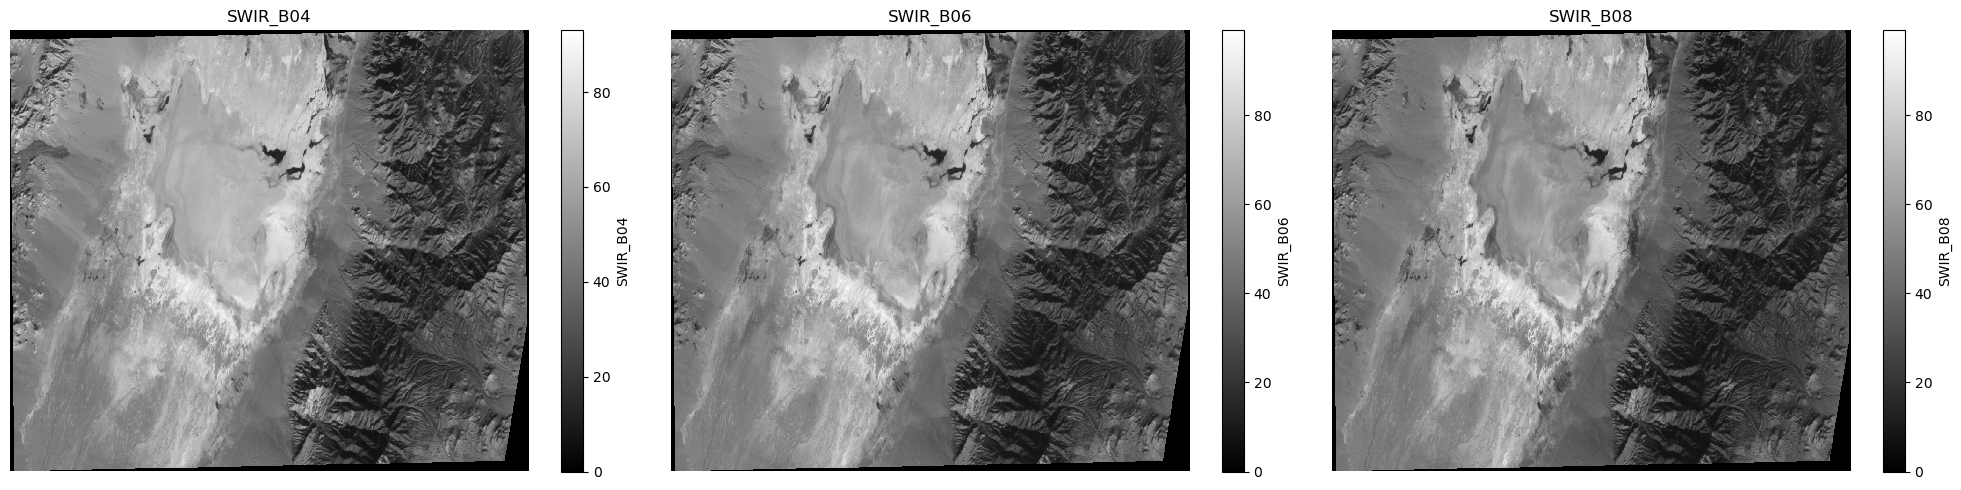

In [21]:
variables = list(aster_composite.data_vars)

ncols = 3
nrows = 1

fix, axes = plt.subplots(nrows, ncols, figsize = (20,5))
axes = axes.ravel()

for i, variable in enumerate(variables):
    ax = axes[i]
    aster_composite[variable].plot.imshow(ax = ax, cmap = 'grey',) 
    ax.set_title(variable)
    ax.axis('off')
plt.tight_layout()
plt.show

### 5.2 Create and Visualize Three band RGB Composite
Finally, we can make three band RGB composite from the `aster_composite` `xarray.Dataset`.

In [22]:
rgb = xr.concat([aster_composite['SWIR_B04'], aster_composite['SWIR_B06'], aster_composite['SWIR_B08']],dim='band')

For before we show our visuaulation we are going to apply a gamma correction to our visuaulation.

In [23]:
def gamma_adjust(rgb, bright=0.3, pct_low=2, pct_high=96):
    """
    Adjust gamma across all bands in the RGB dataset.
    """
    array = (rgb/255).astype(float)
    p_low = np.percentile(array, pct_low)
    p_high = np.percentile(array, pct_high)
    array= (array - p_low) / (p_high - p_low)
    array= np.clip(array, 0, 1)
    # Calculate gamma based on the mean of valid values
    mean_valid = np.nanmean(array)
    gamma = math.log(bright) / math.log(mean_valid)
    # Apply scaling and clip
    scaled = np.full_like(array, np.nan)
    scaled = np.power(array, gamma)
    #print(np.nanmax(scaled))
    rgb = np.clip(scaled, 0, 1)
    return rgb

gamma_corrected = gamma_adjust(rgb)
 

In [24]:
rgb_plot= gamma_corrected.hvplot.rgb(x='x',y='y', bands='band', aspect='equal', width=700, height=500, title='Band 04, 06, 08 Composite, Railroad Valley, Nevada')
rgb_plot

:RGB   [x,y]   (R,G,B)

Next, we can take the same plot above and plot the RGB onto a basemap.

In [25]:
rgb_plot_map = gamma_corrected.hvplot.rgb(x='x',y='y', bands ='band', xlim = (586592.68,  675603.37), ylim = (4317252.16, 4207702.37),
                              tiles = True, crs = 'epsg = 32617', aspect ='equal', width =700, height= 500, 
                              title='Band 04, 06, 08 Composite, Railroad Valley, Nevada')
rgb_plot_map

:Overlay
   .WMTS.I :WMTS   [Longitude,Latitude]
   .RGB.I  :RGB   [x,y]   (R,G,B)

Optional, export pre-gamma corrected RGB as three band GeoTIFF.

In [26]:
rgb.rio.to_raster('rgb.tif')

Success! You have learned how to query and visualize AST_L1T data without downloading any source files. You can now replace the collection short name, GeoJSON file, and temporal range in Section 2 with your own inputs and re-run the notebook.

## Contact Info  

Email: LPDAAC@usgs.gov  
Voice: +1-866-573-3222  
Organization: Land Processes Distributed Active Archive Center (LP DAAC)¹  
Website: <https://www.earthdata.nasa.gov/centers/lp-daac>  

¹Work performed under USGS contract G15PD00467 for NASA contract NNG14HH33I.